#### Loaded only one file ".24" and taken Fs as 20480 (sampling rate). Marked the time "t" cause we will be plotting time series data. Plotted 2000 data from the file.

Total samples: 20480


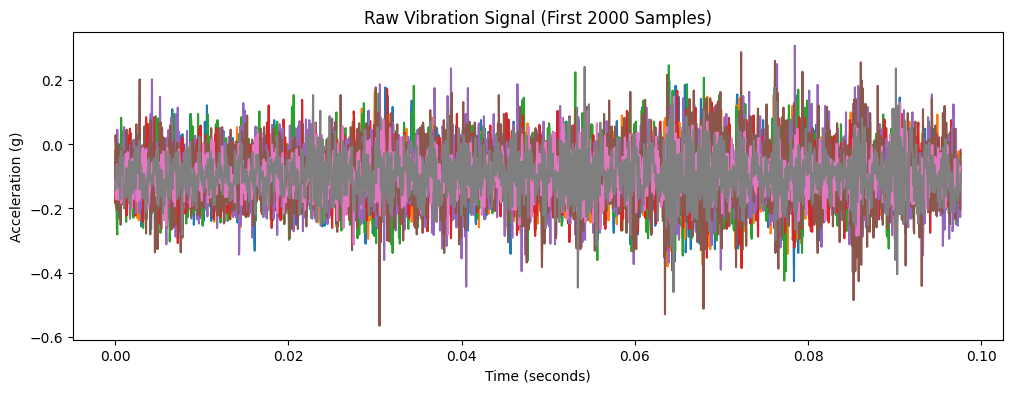

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Updated the path to be relative to the current directory
file_path = "filedata/2003.10.22.12.06.24"

if os.path.exists(file_path):
    # Load raw vibration data
    data = np.loadtxt(file_path)

    Fs = 20480  # Sampling rate (Hz)
    t = np.arange(len(data)) / Fs

    print("Total samples:", len(data))
    plt.figure(figsize=(12,4))
    plt.plot(t[:2000], data[:2000])
    plt.xlabel("Time (seconds)")
    plt.ylabel("Acceleration (g)")
    plt.title("Raw Vibration Signal (First 2000 Samples)")
    plt.show()
else:
    print(f"Error: File not found at {file_path}")
    print("Current working directory:", os.getcwd())
    print("Available files in current directory:", os.listdir('.'))

#### As the data is not centred around zero so we did the DC offset removing to centre it around the 0.

In [37]:
# Ensure data is loaded from the first file for demonstration
file_path = "filedata/2003.10.22.12.06.24"
data = np.loadtxt(file_path)

data_dc = data - np.mean(data)
print("Mean before:", np.mean(data))
print("Mean after :", np.mean(data_dc))

Mean before: -0.09286718139648438
Mean after : 4.206704429243757e-18


#### Used z score method for basic outlier detection in one file with the kernel size of 5. Then copied the data for the no loss in future to prevent the originality.

In [38]:
from scipy.signal import medfilt

mean = np.mean(data_dc)
std = np.std(data_dc)

z_scores = (data_dc - mean) / std
outliers = np.abs(z_scores) > 5
cleaned_data = np.copy(data_dc)
cleaned_data[outliers] = mean

# Filtered signal for visualization
filtered = medfilt(cleaned_data[:2000, 2], kernel_size=5)

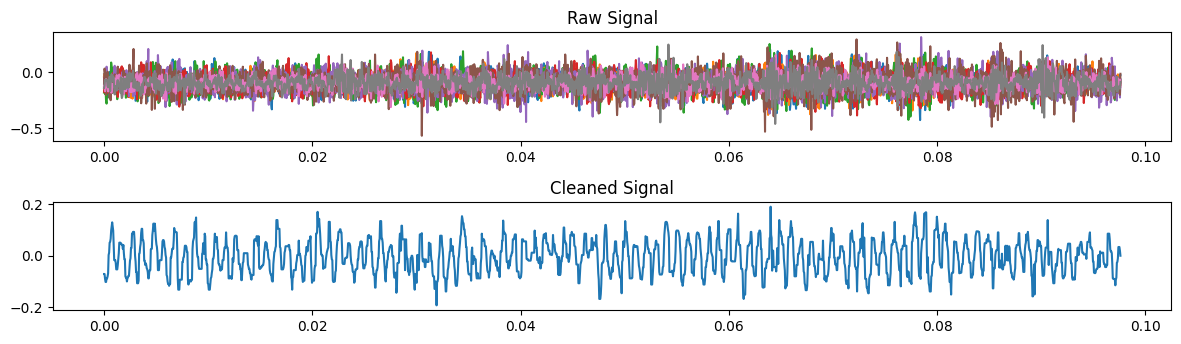

In [39]:
#Plotted the raw and cleaned data for comparison.
plt.figure(figsize=(12,5))

plt.subplot(3,1,1)
plt.plot(t[:2000], data[:2000])
plt.title("Raw Signal")

plt.subplot(3,1,2)
plt.plot(t[:2000], filtered[:2000])
plt.title("Cleaned Signal")


plt.tight_layout()
plt.show()

### *FFT freq domain data

In [40]:
print(cleaned_data.shape) # here we are checking how much channel is there for the signal data and it comes out to be 8 so we individually check the data in each channel of the signal in the above code.

(20480, 8)


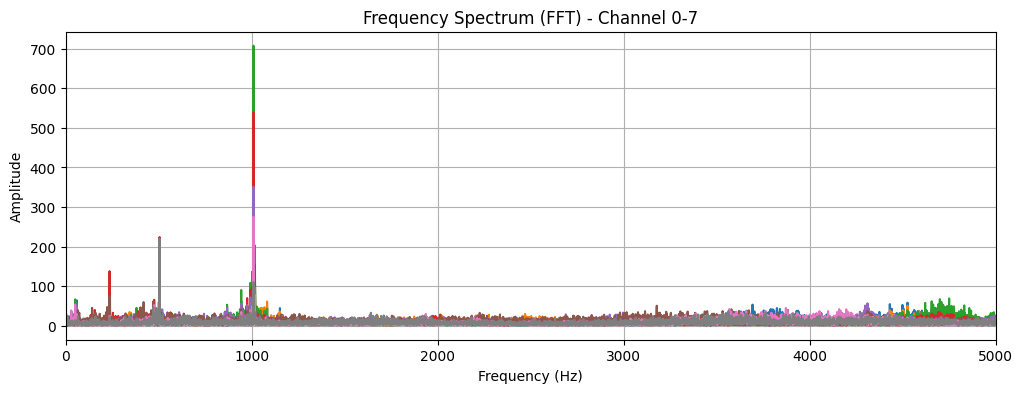

In [105]:
from scipy.fft import rfft, rfftfreq
signals = cleaned_data[:, :8]
N = len(signals)
Fs = 20480
yf = rfft(signals, axis=0)
xf = rfftfreq(N, 1/Fs)
magnitude = np.abs(yf)

plt.figure(figsize=(12,4))
plt.plot(xf, magnitude[:, :8])
plt.xlim(0, 5000)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("Frequency Spectrum (FFT) - Channel 0-7")
plt.grid()
plt.show()

### windowing

In [46]:
signals = cleaned_data[:, :8]
from scipy.signal import windows
# Create the window and reshape it for broadcasting across 8 channels
window = windows.hann(len(signals))[:, np.newaxis]
signal_win = signals * window

from scipy.fft import rfft, rfftfreq
Fs = 20480
N = len(signals)
yf_w = rfft(signal_win, axis=0)
xf_w = rfftfreq(N, 1/Fs)
mag = np.abs(yf_w)

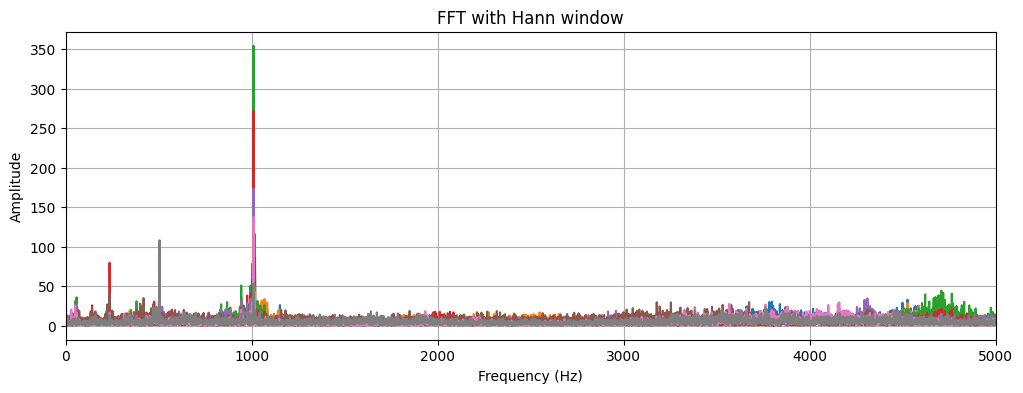

In [47]:
plt.figure(figsize=(12,4))
plt.plot(xf,mag)
plt.xlim(0,5000)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("FFT with Hann window")
plt.grid()
plt.show()

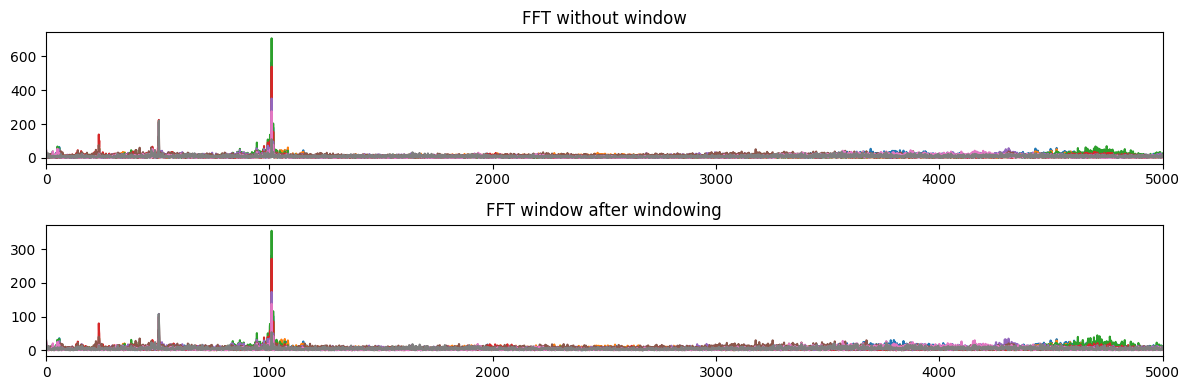

In [48]:
# Comparing windowed vs non windowed for clarification.
plt.figure(figsize=(12,4))
plt.subplot(2,1,1)
plt.plot(xf, magnitude)
plt.title("FFT without window")
plt.xlim(0,5000)

plt.subplot(2,1,2)
plt.plot(xf,mag)
plt.title("FFT window after windowing")
plt.xlim(0,5000)
plt.tight_layout()
plt.show()

### PSD using welch's method after FFT

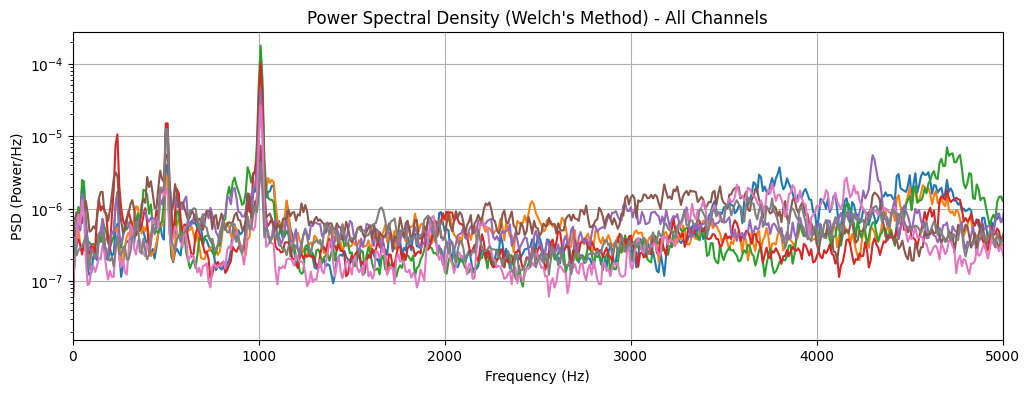

In [50]:
from scipy.signal import welch

Fs = 20480
signals = cleaned_data[:, :8]

freqs, psd = welch(
    signals,
    fs=Fs,
    window='hann',
    nperseg=2048,
    noverlap=1024,
    scaling='density',
    axis=0
)

plt.figure(figsize=(12,4))
plt.semilogy(freqs, psd)
plt.title("Power Spectral Density (Welch's Method) - All Channels")
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD (Power/Hz)")
plt.xlim(0, 5000)
plt.grid()
plt.show()

### Plotting of FFT and PSD

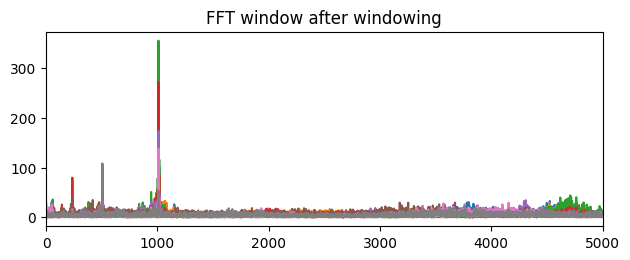

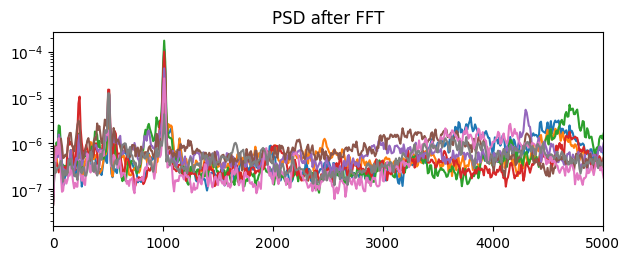

In [51]:
#Plotting FFT vs PSD
plt.subplot(2,1,1)
plt.plot(xf,mag)
plt.title("FFT window after windowing")
plt.xlim(0,5000)
plt.tight_layout()
plt.show()

plt.subplot(2,1,2)
plt.semilogy(freqs, psd) #plotting using log scale.
plt.title("PSD after FFT")
plt.xlim(0,5000)
plt.tight_layout()
plt.show()


### STFT and Spectrogram

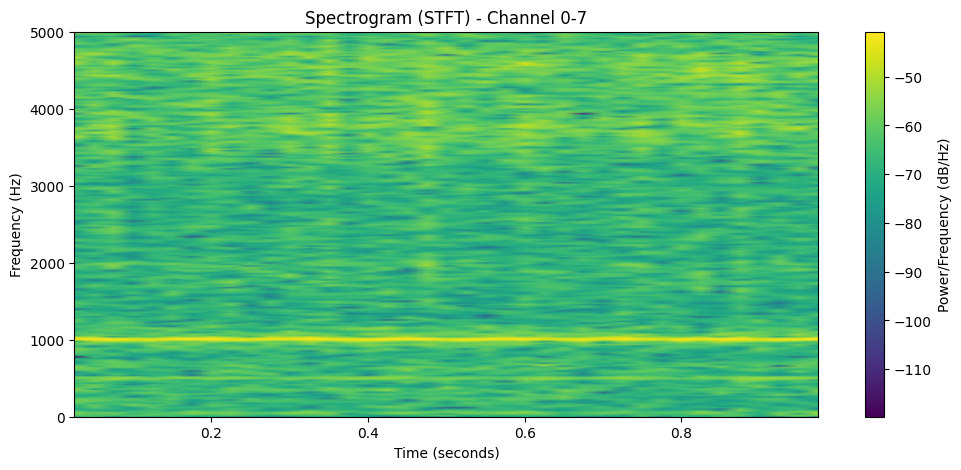

In [106]:
signals = cleaned_data[:, 0]
Fs = 20480
from scipy.signal import spectrogram

f, t, Sxx = spectrogram( #defining Spectogram function with all the parameters
    signals,
    fs=Fs,
    window='hann',
    nperseg=1024,
    noverlap=512,
    scaling='density',
    axis=0
)
plt.figure(figsize=(12,5))
plt.pcolormesh(t, f, 10*np.log10(Sxx + 1e-12), shading='gouraud') # added small epsilon to avoid log(0)
plt.colorbar(label='Power/Frequency (dB/Hz)')
plt.ylabel('Frequency (Hz)')
plt.xlabel('Time (seconds)')
plt.ylim(0, 5000)
plt.title('Spectrogram (STFT) - Channel 0-7')
plt.show()

### Creating feature vector

In [56]:
signals=cleaned_data[:, :8] #finding rms of the data of the second channel.
rms=np.sqrt(np.mean(signals**2))
print(rms)

0.07963995060730075


In [57]:
ptp = np.max(signals) - np.min(signals)# finding peak to peak data of the 2nd channel of the signal.
print(ptp)

0.796


In [59]:
import numpy as np # Calculating the band power and the energy in the particular band width. here we have taken 800-1200hz frequency.

def band_power(freqs, psd, f_low, f_high):
    idx = (freqs >= f_low) & (freqs <= f_high)
    # Use axis=0 if psd is 2D to calculate power for all channels
    return np.trapezoid(psd[idx, :], freqs[idx], axis=0)
bp_1k = band_power(freqs, psd, 800, 1200)
print("Band power (800–1200 Hz) per channel:", bp_1k)

Band power (800–1200 Hz) per channel: [0.00220576 0.0010581  0.00349865 0.0019167  0.00107861 0.00042569
 0.00055964 0.00024372]


### Defined features : rms, std, kurt, bp_1k, centroid, bandwidth, flatness, entropy, crest_factor, shape_factor, impulsive_factor, clearance_factor.

In [60]:
import numpy as np
from scipy.signal import welch
from scipy.stats import kurtosis

def extract_features(segment, Fs):
    all_features = []

    # Loop over all channels
    for ch in range(segment.shape[1]):
        signals = segment[:, ch]   # 1D signal for this channel

        # -------- Time Domain --------
        rms = np.sqrt(np.mean(signals**2))
        std = np.std(signals)
        kurt = kurtosis(signals, fisher=False)

        # -------- Frequency Domain --------
        freqs, psd = welch(signals, fs=Fs, nperseg=min(len(signals), 2048))

        def band_power(f, p, f_low, f_high):
            idx = (f >= f_low) & (f <= f_high)
            return np.trapezoid(p[idx], f[idx]) if np.any(idx) else 0

        bp_1k = band_power(freqs, psd, 800, 1200)

        centroid = np.sum(freqs * psd) / (np.sum(psd) + 1e-12)
        bandwidth = np.sqrt(np.sum(((freqs - centroid)**2) * psd) / (np.sum(psd) + 1e-12))
        flatness = np.exp(np.mean(np.log(psd + 1e-12))) / (np.mean(psd) + 1e-12)

        psd_norm = psd / (np.sum(psd) + 1e-12)
        entropy = -np.sum(psd_norm * np.log(psd_norm + 1e-12))

        # -------- Shape Features --------
        peak = np.max(np.abs(signals))
        mean_abs = np.mean(np.abs(signals))
        mean_sqrt = np.mean(np.sqrt(np.abs(signals)))

        features = [
            rms, std, kurt, bp_1k,
            centroid, bandwidth, flatness, entropy,
            peak / (rms + 1e-12),
            rms / (mean_abs + 1e-12),
            peak / (mean_abs + 1e-12),
            peak / (mean_sqrt**2 + 1e-12)
        ]

        # Add channel features
        all_features.extend(features)

    return np.array(all_features)

In [61]:
#Creating segments now:
Fs = 20480
signals = cleaned_data[:, :8]

window_size = Fs // 200
segments = []

for start in range(0, len(signals) - window_size + 1, window_size):
    segment = signals[start:start + window_size, :]
    segments.append(segment)


# Creating dataset for ML as in X
X = []

for segment in segments:
    features = extract_features(segment, Fs)
    X.append(features)

X = np.array(X)

print("Dataset shape:", X.shape) # it checks the shape (1,8) tells us : 1 is the segment with 8 features at once.

Dataset shape: (200, 96)


In [62]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

#### Using Isolation forest as our primary ML model initially.

In [63]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42
)

model.fit(X_scaled)

IsolationForest(contamination=0.05, n_estimators=200, random_state=42)

In [64]:
labels = model.predict(X_scaled)
print(labels) # 1 is normal and -1 is anomaly

[ 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1  1  1 -1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1 -1  1 -1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1
  1  1  1  1  1 -1  1  1 -1  1  1 -1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1]


In [65]:
import numpy as np

anomaly_indices = np.where(labels == -1)[0]

print("Anomaly segments:", anomaly_indices)

Anomaly segments: [ 42  64  68  95 147 149 166 173 176 179]


In [66]:
print("Feature matrix:")
print(X)

Feature matrix:
[[0.07078049 0.07013534 2.31942543 ... 1.24128765 3.36723967 4.01747757]
 [0.08551488 0.08549182 2.60781269 ... 1.25929489 4.49085499 5.27959766]
 [0.07680485 0.07660445 2.57170925 ... 1.22650312 2.81172352 3.25793681]
 ...
 [0.07881881 0.07876873 2.25666779 ... 1.2781004  4.41023547 5.25589312]
 [0.07224299 0.07223846 2.61544948 ... 1.25293778 3.01909443 3.58623256]
 [0.08362534 0.08328608 2.78234392 ... 1.24618872 3.20323208 3.7941457 ]]


In [67]:
print("Segment 9 features:", X[9])# we can check the feature of the anaomaly segment.
print("Segment 8 features:", X[8])

Segment 9 features: [8.38007272e-02 8.32188418e-02 3.01472763e+00 8.27282091e-04
 3.59200195e+03 2.02161017e+03 2.83078020e-01 2.87019664e+00
 2.97291953e+00 1.23262465e+00 3.66449389e+00 4.26301531e+00
 7.55537348e-02 7.52337182e-02 2.53324657e+00 2.43286474e-04
 4.03926086e+03 2.57441900e+03 3.76463735e-01 3.22612983e+00
 2.45034636e+00 1.20568301e+00 2.95434097e+00 3.36477253e+00
 9.08222079e-02 9.08147712e-02 3.20136734e+00 2.23225890e-03
 2.44774183e+03 2.24421937e+03 3.46334462e-01 2.91924995e+00
 2.98531411e+00 1.26836292e+00 3.78646173e+00 4.53114464e+00
 8.57084492e-02 8.56954161e-02 2.61514939e+00 5.67051449e-04
 3.36335572e+03 3.13933459e+03 3.80377828e-01 3.13269526e+00
 2.25336965e+00 1.22978078e+00 2.77115069e+00 3.21061589e+00
 9.65781409e-02 9.65466726e-02 3.57144512e+00 4.58695968e-04
 4.92170755e+03 2.93524969e+03 5.01339325e-01 3.57768267e+00
 3.13873114e+00 1.25651135e+00 3.94385130e+00 4.57258593e+00
 1.01609382e-01 1.00927662e-01 2.83540867e+00 1.84438546e-04
 4.8

### Plotted anomalies in one file using ISO.

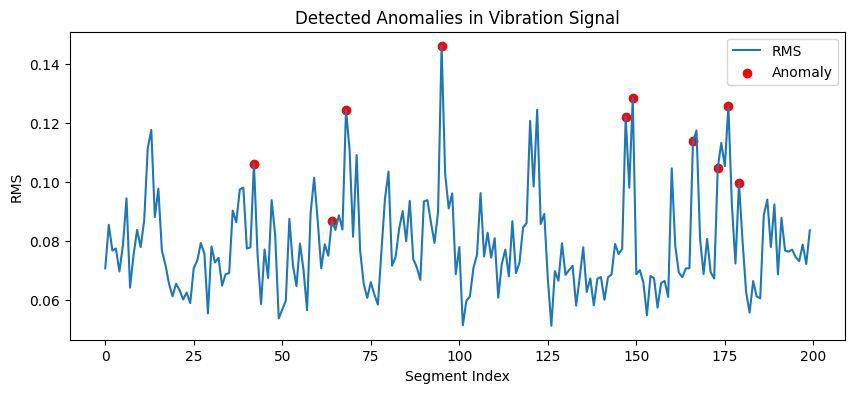

In [68]:
import matplotlib.pyplot as plt

rms_values = X[:,0]

plt.figure(figsize=(10,4))
plt.plot(rms_values, label="RMS")

plt.scatter(anomaly_indices,
            rms_values[anomaly_indices],
            color='red',
            label='Anomaly')

plt.xlabel("Segment Index")
plt.ylabel("RMS")
plt.title("Detected Anomalies in Vibration Signal")
plt.legend()
plt.show()

#### Did Hilbert Transformation for envelope analysis.


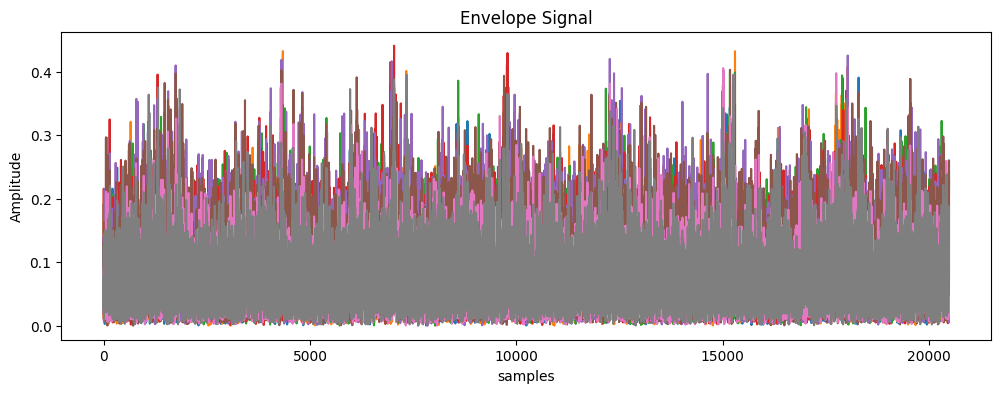

In [69]:
# Did envelope analysis cause FFT alone is not enough.
from scipy.signal import hilbert
signal=signals
analytic_signal=hilbert(signal)
envelope=np.abs(analytic_signal)
plt.figure(figsize=(12,4))
plt.plot(envelope)
plt.title("Envelope Signal")
plt.xlabel("samples")
plt.ylabel("Amplitude")
plt.show()

#### Plotted envelope spectrum

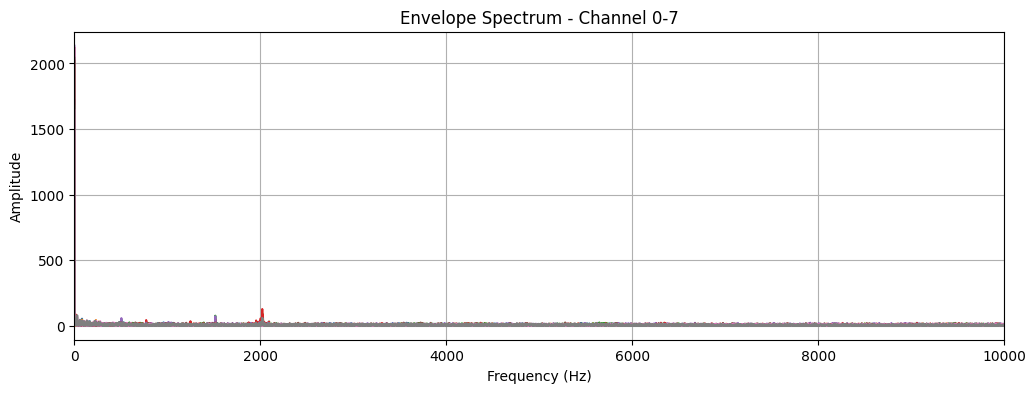

In [108]:
yf_env = np.abs(np.fft.rfft(envelope, axis=0))

xf_env = np.fft.rfftfreq(len(envelope), 1/Fs)

plt.figure(figsize=(12,4))

# Plotting the envelope spectrum (Channel 0 as an example)
plt.plot(xf_env, yf_env[:, :8])

plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("Envelope Spectrum - Channel 0-7")

plt.xlim(0, 10000)
plt.grid()
plt.show()

The result till now is "no fault" getting. If there have been a fault in the spectrum then the peaks would have been periodic and the frequency would be increasing constantly.

In [73]:
mask = (xf_env >= 500) & (xf_env <= 510)
xf_filtered = xf_env[mask]
yf_filtered = yf_env[mask]
print(yf_filtered)

[[ 6.99422598  6.91484284 14.54170278 14.79724825 15.26409227 20.54803838
  15.93328661  8.09900171]
 [21.5208551  11.78931748  9.77894828 15.98974472 18.77337315 17.61364924
   9.94380455 14.45873111]
 [ 2.6256924   8.22811142 12.65063791  1.22438477 17.32811355 15.84558706
   6.07171355  0.7580788 ]
 [ 6.07785193  4.54656574  5.71695172  8.5553535   9.08878375  6.75611104
   8.16906039 10.1236509 ]
 [ 9.33970096 11.62310531  9.71303901  2.5557519   0.99340573 13.37006653
   8.36885536 11.67509464]
 [15.99008128 35.45731813 47.00221292 30.41769661 57.84499869 25.01848102
  20.31286083 19.67575905]
 [ 4.10961781  6.20846552  7.45315177  9.44672099  7.97254129 14.70897177
   4.88539444  1.48875051]
 [ 4.03145287  6.02851772  2.01912846  7.77100313 11.78661603 11.04220161
   6.52984868  1.66920472]
 [ 8.86098531 11.4537615   6.67815349  8.32690007  8.34981063 19.76754838
  12.86757858  6.15885805]
 [18.89726738 26.89378476  6.27759498 16.38257353 19.76273935 15.94535419
  16.87027211 19.

form the bove code i tried printing the y coordinate for the spikes from the spectrum of envelop. but turns out nothing is much wrong here, everythig is just normal.  

### Using OneClassSVM

In [74]:
# Moved to our next model for cross verification of the anamolies.
from sklearn.svm import OneClassSVM
svm_model=OneClassSVM(
    kernel='rbf',
    nu=0.05,
    gamma='scale'
)
svm_labels=svm_model.fit_predict(X_scaled)
print(svm_labels)

[-1  1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1  1  1 -1
  1  1  1  1 -1  1  1  1  1  1  1  1  1 -1  1  1  1  1 -1  1  1  1  1  1
 -1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1  1  1  1  1 -1  1  1  1
 -1 -1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1 -1  1  1 -1  1  1  1  1  1  1  1 -1 -1  1  1  1  1 -1  1 -1
  1  1 -1  1  1 -1  1  1  1  1  1  1 -1  1  1  1  1  1  1  1  1 -1 -1  1
  1  1  1  1  1 -1  1 -1 -1  1  1  1 -1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1]


### Using Autoencoders

In [75]:
# One of the best models for anomalies detection as per the previous research.
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

input_dim = X_scaled.shape[1]

input_layer = Input(shape=(input_dim,))
encoded = Dense(8, activation='relu')(input_layer)
decoded = Dense(input_dim, activation='linear')(encoded)

autoencoder = Model(inputs=input_layer, outputs=decoded)
autoencoder.compile(optimizer='adam', loss='mse')

autoencoder.fit(X_scaled, X_scaled,
                epochs=50,
                batch_size=16,
                verbose=0)

In [76]:
# did reconstruction as a part of our AE.
reconstructions = autoencoder.predict(X_scaled)
mse = np.mean((X_scaled - reconstructions)**2, axis=1)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


In [77]:
threshold = np.percentile(mse, 95)

ae_labels = np.where(mse > threshold, -1, 1)
print(ae_labels) # printing anomalies found by AE.

[ 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1  1  1  1  1  1  1
 -1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1 -1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1  1
  1  1  1  1  1 -1  1 -1  1  1  1 -1 -1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1]


### Comparing results

In [78]:
print("Isolation Forest anomalies:", np.sum(labels == -1))
print("One-Class SVM anomalies:", np.sum(svm_labels == -1))
print("Autoencoder anomalies:", np.sum(ae_labels == -1))

Isolation Forest anomalies: 10
One-Class SVM anomalies: 27
Autoencoder anomalies: 10


### plotting of three models

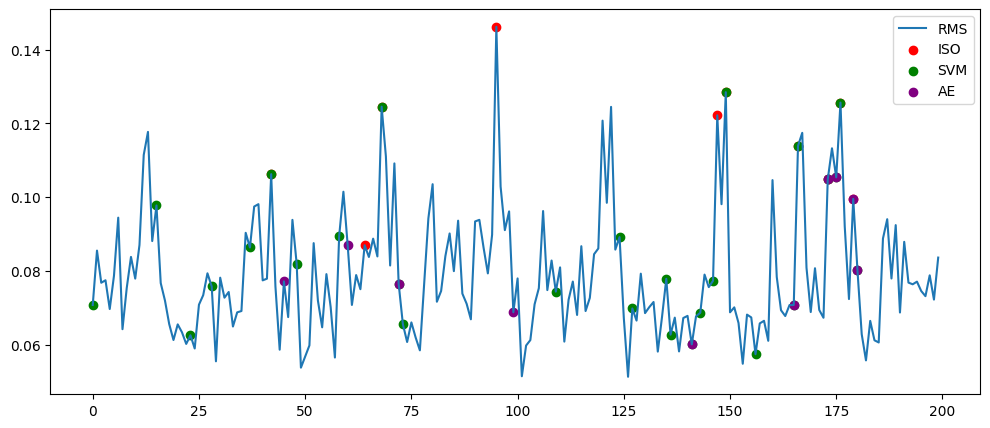

In [79]:
plt.figure(figsize=(12,5))

plt.plot(X[:,0], label="RMS")

plt.scatter(np.where(labels==-1),
            X[labels==-1,0],
            color='red', label='ISO')

plt.scatter(np.where(svm_labels==-1),
            X[svm_labels==-1,0],
            color='green', label='SVM')

plt.scatter(np.where(ae_labels==-1),
            X[ae_labels==-1,0],
            color='purple', label='AE')

plt.legend()
plt.show()

In [81]:
combined = (labels == -1).astype(int) + \
           (svm_labels == -1).astype(int) + \
           (ae_labels == -1).astype(int)

# High confidence anomalies
strong_anomalies = np.where(combined >= 2)[0]
print(strong_anomalies)

[ 42  68  72 141 149 165 166 173 175 176 179 180]


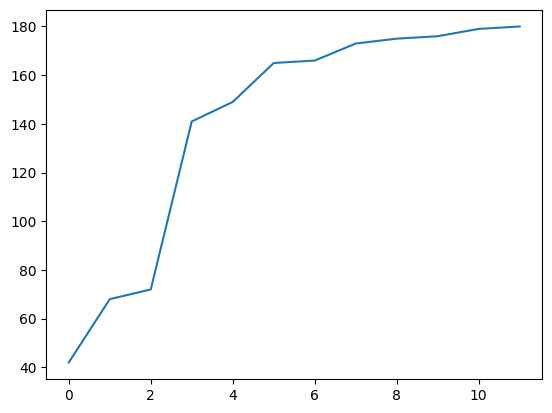

In [82]:
plt.plot(strong_anomalies)

### Counting anomaly over time for each second

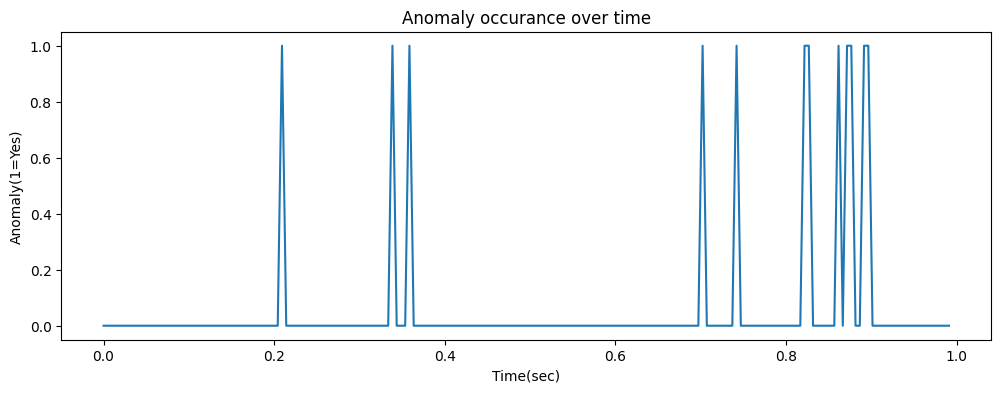

In [83]:
time=np.arange(len(X))*(window_size/Fs)
anomaly_signal=(combined>=2).astype(int)
plt.figure(figsize=(12,4))
plt.plot(time,anomaly_signal)
plt.xlabel("Time(sec)")
plt.ylabel("Anomaly(1=Yes)")
plt.title("Anomaly occurance over time")
plt.show()

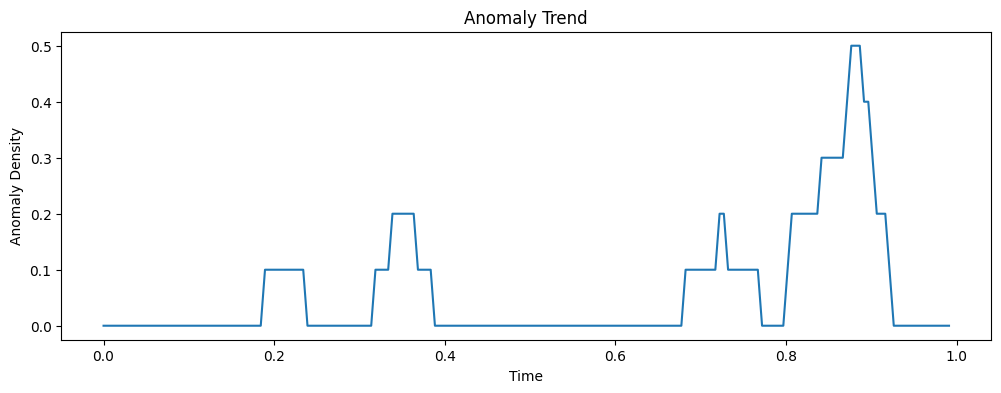

In [84]:
window = 10
trend = np.convolve(anomaly_signal, np.ones(window)/window, mode='same')

plt.figure(figsize=(12,4))
plt.plot(time, trend)
plt.title("Anomaly Trend")
plt.xlabel("Time")
plt.ylabel("Anomaly Density")
plt.show()

Text(0.5, 1.0, 'rms over time')

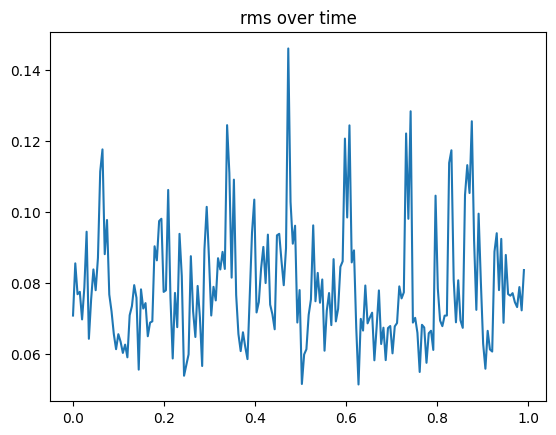

In [85]:
# plotting feature values individually.
plt.plot(time, X[:,0]) #in feature vector the index 0 is rms
plt.title("rms over time")

### Now we will check for multiple files and do some more work

In [86]:
def extract_features(segment, Fs):
    all_features = []

    # Loop through all channels
    for ch in range(segment.shape[1]):
        signals = segment[:, ch]

        # ---- Time Domain ----
        rms = np.sqrt(np.mean(signals**2))
        std = np.std(signals)
        kurt = kurtosis(signals, fisher=False)

        # ---- Frequency Domain ----
        freqs, psd = welch(signals, fs=Fs)

        centroid = np.sum(freqs * psd) / (np.sum(psd) + 1e-12)
        bandwidth = np.sqrt(np.sum(((freqs - centroid)**2) * psd) / (np.sum(psd) + 1e-12))
        flatness = np.exp(np.mean(np.log(psd + 1e-12))) / (np.mean(psd) + 1e-12)

        psd_norm = psd / (np.sum(psd) + 1e-12)
        entropy = -np.sum(psd_norm * np.log(psd_norm + 1e-12))

        # ---- Shape Features ----
        peak = np.max(np.abs(signals))
        mean_abs = np.mean(np.abs(signals))
        mean_sqrt = np.mean(np.sqrt(np.abs(signals)))

        crest = peak / (rms + 1e-12)
        shape = rms / (mean_abs + 1e-12)
        impulse = peak / (mean_abs + 1e-12)
        clearance = peak / (mean_sqrt**2 + 1e-12)

        features = [
            rms, std, kurt,
            centroid, bandwidth, flatness, entropy,
            crest, shape, impulse, clearance
        ]

        all_features.extend(features)

    return np.array(all_features)



### Here we have defined segments again for the next all file work.

In [87]:
def create_segments(signals, Fs):
    window_size = Fs // 200
    segments = []

    for start in range(0, len(signals) - window_size + 1, window_size):
        segments.append(signals[start:start + window_size])

    return segments

### Loading AE

In [88]:
def build_autoencoder(input_dim):
    input_layer = Input(shape=(input_dim,))
    encoded = Dense(8, activation='relu')(input_layer)
    decoded = Dense(input_dim, activation='linear')(encoded)

    model = Model(inputs=input_layer, outputs=decoded)
    model.compile(optimizer='adam', loss='mse')

    return model

### Main pipeline

In [99]:
import os
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM

files = sorted(os.listdir(folder_path))
print("Files found:", files)

anomaly_counts = []
anomaly_scores = []
all_anomaly_indices = []

for file in files:

    print(f"\nProcessing: {file}")

    # -------- LOAD FILE --------
    file_path = os.path.join(folder_path, file)
    data = np.loadtxt(file_path)
    signals = data[:, :8]

    # -------- SEGMENTATION --------
    segments = []
    for start in range(0, len(signals) - window_size + 1, window_size):
        segment = signals[start:start + window_size, :]
        segments.append(segment)

    # -------- FEATURE EXTRACTION --------
    X = []
    for segment in segments:
        X.append(extract_features(segment, Fs))

    X = np.array(X)

    print("Feature variance:", np.var(X))  # debug

    # -------- SCALING --------
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # -------- MODELS --------
    iso = IsolationForest(contamination=0.1, random_state=42)
    iso_labels = iso.fit_predict(X_scaled)

    svm = OneClassSVM(nu=0.1)
    svm_labels = svm.fit_predict(X_scaled)

    # -------- AUTOENCODER --------
    ae = build_autoencoder(X_scaled.shape[1])
    ae.fit(X_scaled, X_scaled, epochs=10, batch_size=16, verbose=0)

    recon = ae.predict(X_scaled)
    mse = np.mean((X_scaled - recon)**2, axis=1)

    threshold_ae = np.percentile(mse, 95)
    ae_labels = np.where(mse > threshold_ae, -1, 1)

    # -------- ENSEMBLE --------
    iso_bin = (iso_labels == -1).astype(int)
    svm_bin = (svm_labels == -1).astype(int)
    ae_bin  = (ae_labels == -1).astype(int)

    print("ISO:", np.sum(iso_bin),
          "SVM:", np.sum(svm_bin),
          "AE:", np.sum(ae_bin))

    # -------- ADAPTIVE WEIGHTS --------
    iso_conf = np.mean(iso_bin)
    svm_conf = np.mean(svm_bin)
    ae_conf  = np.mean(ae_bin)

    total_conf = iso_conf + svm_conf + ae_conf + 1e-6

    w_iso = iso_conf / total_conf
    w_svm = svm_conf / total_conf
    w_ae  = ae_conf  / total_conf

    # -------- WEIGHTED SCORE --------
    weighted_score = (
        w_iso * iso_bin +
        w_svm * svm_bin +
        w_ae  * ae_bin
    )

    final_anomalies = (weighted_score >= 0.5).astype(int)

    # -------- RESULTS --------
    anomaly_indices = np.where(final_anomalies == 1)[0]
    anomaly_count = np.sum(final_anomalies)
    anomaly_score = np.sum(weighted_score)

    print(f"Count: {anomaly_count}")
    print(f"Score: {anomaly_score:.2f}")
    print(f"Indices: {anomaly_indices}")

    anomaly_counts.append(anomaly_count)
    anomaly_scores.append(anomaly_score)
    all_anomaly_indices.append(anomaly_indices)


Files found: ['2003.10.22.12.06.24', '2003.10.22.12.09.13', '2003.10.22.12.14.13', '2003.10.22.12.19.13', '2003.10.22.12.24.13', '2003.10.22.12.29.13', '2003.10.22.12.34.13', '2003.10.22.12.39.13', '2003.10.22.12.44.13', '2003.10.22.12.49.13', '2003.10.22.12.54.13', '2003.10.22.12.59.13', '2003.10.22.13.04.13', '2003.10.22.13.09.13', '2003.10.22.13.14.13', '2003.10.22.13.19.13', '2003.10.22.13.24.13', '2003.10.22.13.29.13', '2003.10.22.13.34.13', '2003.10.22.13.39.13', '2003.10.22.13.44.13', '2003.10.22.13.49.13', '2003.10.22.13.54.13', '2003.10.22.13.59.13', '2003.10.22.14.04.13', '2003.10.22.14.09.13', '2003.10.22.14.14.13', '2003.10.22.14.19.13', '2003.10.22.14.24.13', '2003.10.22.14.29.13', '2003.10.22.14.34.13', '2003.10.22.14.39.13', '2003.10.22.14.44.13', '2003.10.22.14.49.13', '2003.10.22.14.54.13', '2003.10.22.14.59.13', '2003.10.22.15.04.13', '2003.10.22.15.09.13']

Processing: 2003.10.22.12.06.24


/tmp/ipykernel_15525/3657416756.py:14: UserWarning: nperseg=256 is greater than signal length max(len(x), len(y)) = 102, using nperseg = 102
  freqs, psd = welch(signals, fs=Fs)


Feature variance: 1714930.6569942352
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
ISO: 20 SVM: 29 AE: 10
Count: 16
Score: 22.73
Indices: [ 12  42  68  69  71  95 120 147 149 153 160 166 173 175 176 179]

Processing: 2003.10.22.12.09.13


/tmp/ipykernel_15525/3657416756.py:14: UserWarning: nperseg=256 is greater than signal length max(len(x), len(y)) = 102, using nperseg = 102
  freqs, psd = welch(signals, fs=Fs)


Feature variance: 1689793.8852231386
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
ISO: 20 SVM: 36 AE: 10
Count: 36
Score: 27.21
Indices: [  0   1   9  29  31  47  48  51  55  60  71  74  75  78  85  88  95 104
 106 109 120 123 125 131 132 137 143 157 158 159 160 175 182 184 185 191]

Processing: 2003.10.22.12.14.13


...

Feature variance: 1689729.0324604898
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
ISO: 20 SVM: 29 AE: 10
Count: 15
Score: 22.73
Indices: [  2  25  27  50  52  79  90  97 106 108 133 160 184 186 187]

Processing: 2003.10.22.15.04.13


/tmp/ipykernel_15525/3657416756.py:14: UserWarning: nperseg=256 is greater than signal length max(len(x), len(y)) = 102, using nperseg = 102
  freqs, psd = welch(signals, fs=Fs)


Feature variance: 1704028.9149561014
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
ISO: 20 SVM: 32 AE: 10
Count: 32
Score: 24.58
Indices: [  1   2   8  11  26  29  30  31  33  36  42  48  52  53  59  61  79  81
 109 140 149 156 157 158 160 162 168 169 181 188 189 193]

Processing: 2003.10.22.15.09.13


/tmp/ipykernel_15525/3657416756.py:14: UserWarning: nperseg=256 is greater than signal length max(len(x), len(y)) = 102, using nperseg = 102
  freqs, psd = welch(signals, fs=Fs)


Feature variance: 1693155.6764689137
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
ISO: 20 SVM: 29 AE: 10
Count: 14
Score: 22.73
Indices: [ 12  14  41  56  68  81 103 119 122 146 149 151 175 178]


### Plotting graph for multiple file index with anomaly score.

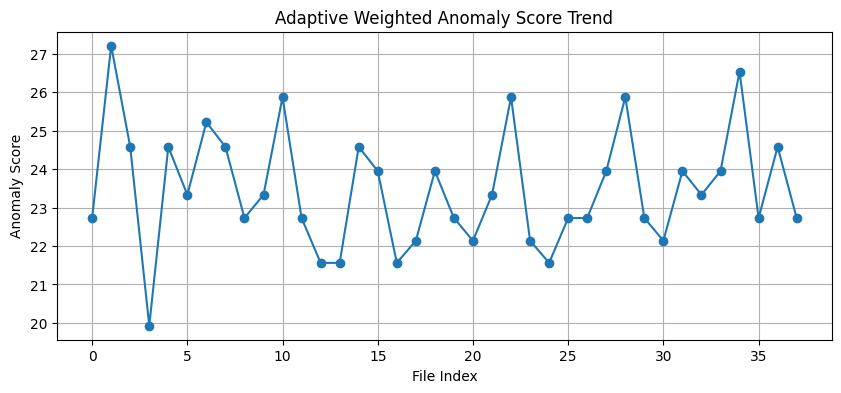

In [100]:
# Anomaly score tells us how abnormal the data is?
plt.figure(figsize=(10,4))
plt.plot(anomaly_scores, marker='o')

plt.title("Adaptive Weighted Anomaly Score Trend")
plt.xlabel("File Index")
plt.ylabel("Anomaly Score")

plt.grid()
plt.show()

### Anomaly score with trend

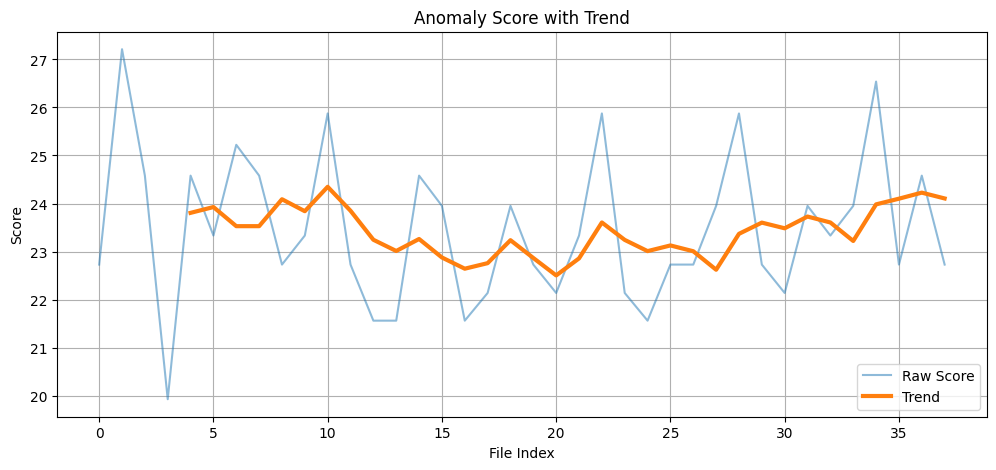

In [101]:
import numpy as np

window = 5
smooth = np.convolve(anomaly_scores, np.ones(window)/window, mode='valid')

plt.figure(figsize=(12,5))
plt.plot(anomaly_scores, label="Raw Score", alpha=0.5)
plt.plot(range(window-1, len(anomaly_scores)), smooth, linewidth=3, label="Trend")

plt.legend()
plt.title("Anomaly Score with Trend")
plt.xlabel("File Index")
plt.ylabel("Score")
plt.grid()
plt.show()

In [102]:
print(f"Weights → ISO: {w_iso:.2f}, SVM: {w_svm:.2f}, AE: {w_ae:.2f}")

Weights → ISO: 0.34, SVM: 0.49, AE: 0.17


### Anomaly count

In [103]:
for i in range(len(anomaly_counts)):
    print(f"\nFile {i}:")
    print(f"Count: {anomaly_counts[i]}")
    print(f"Score: {anomaly_scores[i]:.2f}")
    print(f"Indices: {all_anomaly_indices[i]}")


File 0:
Count: 16
Score: 22.73
Indices: [ 12  42  68  69  71  95 120 147 149 153 160 166 173 175 176 179]

File 1:
Count: 36
Score: 27.21
Indices: [  0   1   9  29  31  47  48  51  55  60  71  74  75  78  85  88  95 104
 106 109 120 123 125 131 132 137 143 157 158 159 160 175 182 184 185 191]

File 2:
Count: 32
Score: 24.58
Indices: [  1  13  14  23  36  38  39  54  55  56  61  64  65  68  69  84  88  94
  97 103 109 122 126 143 146 148 149 170 175 180 187 190]

File 3:
Count: 13
Score: 19.93
Indices: [  5  34  35  51  64  88  91 141 155 157 169 195 199]

File 4:
Count: 32
Score: 24.58
Indices: [  6   7   8  10  11  28  37  47  53  61  63  69  88  90  91  95  97 108
 109 117 128 140 143 144 145 147 150 157 161 163 171 188]

File 5:
Count: 8
Score: 23.33
Indices: [ 20  74  77 101 126 128 130 180]

File 6:
Count: 33
Score: 25.22
Indices: [  4  12  19  24  26  29  30  32  37  39  46  47  71  72  74  79  84  90
 102 105 115 119 137 140 142 143 163 164 176 185 190 192 199]

File 7:
Count: 

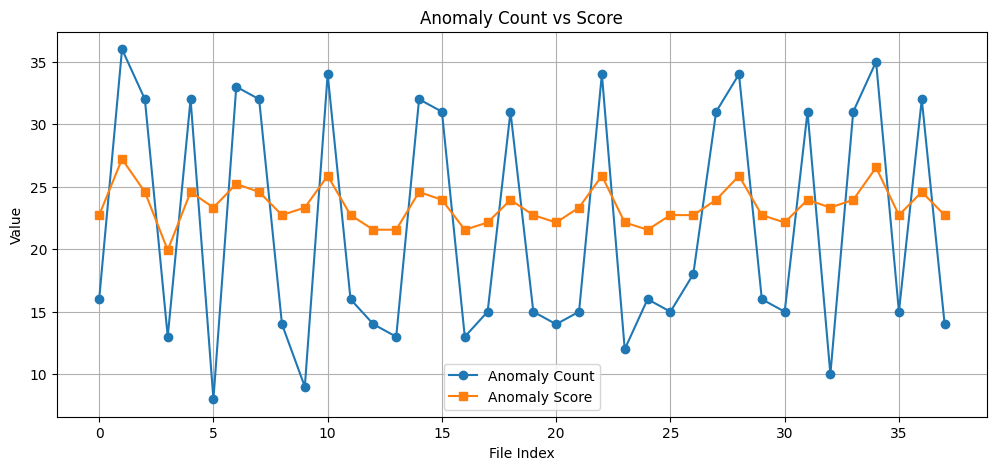

In [104]:
plt.figure(figsize=(12,5))

plt.plot(anomaly_counts, label="Anomaly Count", marker='o')
plt.plot(anomaly_scores, label="Anomaly Score", marker='s')

plt.title("Anomaly Count vs Score")
plt.xlabel("File Index")
plt.ylabel("Value")

plt.legend()
plt.grid()

plt.show()